# Load libraries

In [14]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
import time

# Load data

In [15]:
data = load_breast_cancer()
X = pd.DataFrame(data["data"], columns=data['feature_names'])
y = data["target"]

# Split dataset into training set and test set

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create adaboost classifer object

In [17]:
abc = AdaBoostClassifier(random_state=42)

# Train Adaboost Classifer
model = abc.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = model.predict(X_test)

# Model Evaluation

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [19]:
start_time = time.time()

cv_score = cross_val_score(abc, X, y).mean()
print("Average Cross Validation Score = ", cv_score)
print("--- %s seconds ---" % (time.time() - start_time))

Average Cross Validation Score =  0.9683744760130415
--- 0.38493895530700684 seconds ---


# Exercise: Tune parameters

หาจำนวน estimator และ learning rate ที่ดีที่สุดสำหรับชุดข้อมูลนี้

In [20]:
from sklearn.model_selection import GridSearchCV
import numpy as np
parameters = {'n_estimators': [10, 50, 100], 'learning_rate': [0.1, 0.5, 1.0]}

In [21]:
clf = GridSearchCV(abc, parameters)
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.5, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also disp

In [22]:
results = pd.DataFrame(clf.cv_results_)

In [23]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012521,0.000965,0.001078,0.000459,0.1,10,"{'learning_rate': 0.1, 'n_estimators': 10}",0.934066,0.912088,0.967033,0.923077,0.934066,0.934066,0.018388,9
1,0.058721,0.002179,0.002406,0.000315,0.1,50,"{'learning_rate': 0.1, 'n_estimators': 50}",0.934066,0.934066,0.978022,0.967033,0.945055,0.951648,0.017855,7
2,0.119459,0.002398,0.004091,0.000345,0.1,100,"{'learning_rate': 0.1, 'n_estimators': 100}",0.956044,0.956044,0.978022,0.978022,0.956044,0.964835,0.010767,5
3,0.013393,0.000974,0.001072,0.000092,0.5,10,"{'learning_rate': 0.5, 'n_estimators': 10}",0.934066,0.934066,0.967033,0.956044,0.956044,0.949451,0.013187,8
4,0.060020,0.000676,0.002374,0.000368,0.5,50,"{'learning_rate': 0.5, 'n_estimators': 50}",0.978022,0.967033,0.978022,0.978022,0.934066,0.967033,0.017024,4
5,0.113674,0.004836,0.003972,0.000445,0.5,100,"{'learning_rate': 0.5, 'n_estimators': 100}",0.967033,0.967033,1.000000,0.978022,0.945055,0.971429,0.017855,3
6,0.013132,0.000886,0.001356,0.000610,1.0,10,"{'learning_rate': 1.0, 'n_estimators': 10}",0.978022,0.956044,0.989011,0.967033,0.923077,0.962637,0.022628,6
7,0.060413,0.002538,0.002251,0.000069,1.0,50,"{'learning_rate': 1.0, 'n_estimators': 50}",0.978022,0.978022,1.000000,0.978022,0.967033,0.980220,0.010767,1
8,0.111339,0.003619,0.003672,0.000082,1.0,100,"{'learning_rate': 1.0, 'n_estimators': 100}",0.978022,0.978022,0.989011,0.978022,0.956044,0.975824,0.010767,2


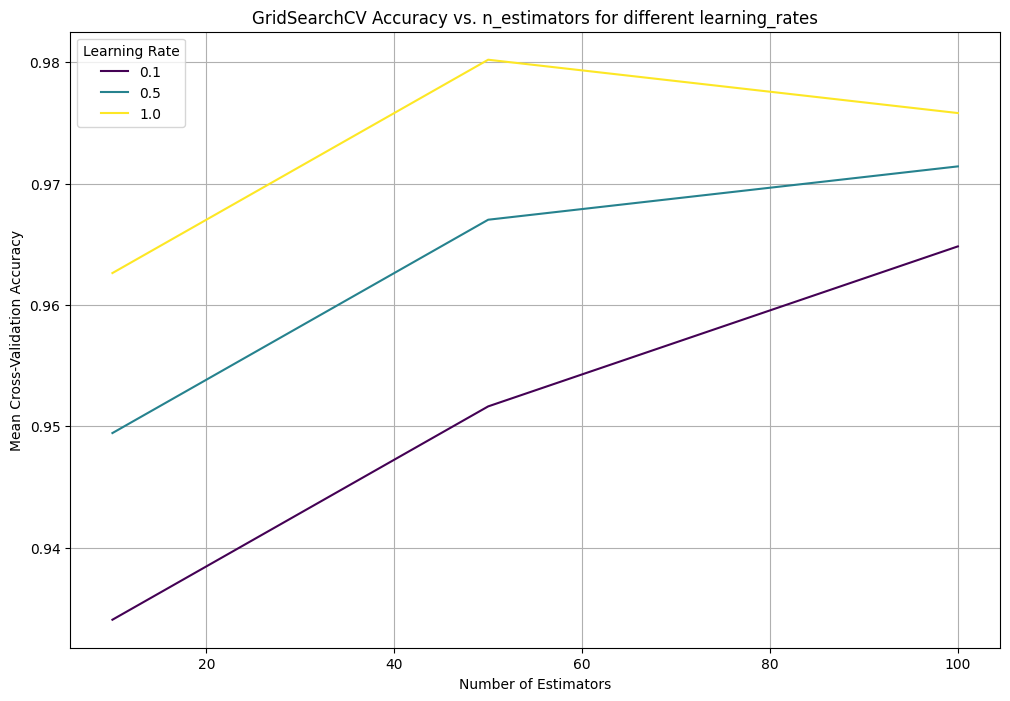

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract n_estimators and learning_rate from the 'params' column
results['n_estimators'] = results['params'].apply(lambda x: x['n_estimators'])
results['learning_rate'] = results['params'].apply(lambda x: x['learning_rate'])

plt.figure(figsize=(12, 8))
sns.lineplot(data=results, x='n_estimators', y='mean_test_score', hue='learning_rate', palette='viridis')
plt.title('GridSearchCV Accuracy vs. n_estimators for different learning_rates')
plt.xlabel('Number of Estimators')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.legend(title='Learning Rate')
plt.show()

In [25]:
clf.best_params_

{'learning_rate': 1.0, 'n_estimators': 50}

In [26]:
clf.best_score_

np.float64(0.9802197802197803)